In [1]:
import numpy as np
from importlib import reload
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import pandas as pd
from scipy.stats import t, truncnorm
import joblib
import torch
import torch.nn as nn

%matplotlib widget

In [2]:
module_path = Path('..').resolve()
if str(module_path) not in sys.path:
    sys.path.insert(0, str(module_path))

This notebook shows how to use an trained emulator.  

First import emulator related libraries

In [24]:
import libs.emulator_libs as libs
libs = reload(libs)

Load the emulator object saved as ".pt" file, using `LoadedSPSEmulator` class.  
This will initialize the emulator, including setting up device (cpu/cuda/mps) according to input, reconstruct the emulator and scaler and make it ready to use.

In [25]:
emulator = libs.LoadedSPSEmulator(checkpoint_path="../emulator_outputs/emulator.pt", device="cpu")

Each emulator is trained SPECIFICALLY for a set of free parameters, and default fixed values. They can thus only be used that way.  
You can check those from `train_param_keys` and `default_params` attributes.

In [26]:
# these are the free parameters trained in the emulator
emulator.train_param_keys

['zred',
 'logmass',
 'logzsol',
 'logsfr_ratios0',
 'logsfr_ratios1',
 'logsfr_ratios2',
 'logsfr_ratios3',
 'dust2',
 'dust_index',
 'duste_qpah']

In [27]:
# These are fixed parameters & settings during training of the emulator
emulator.default_params

{'nbins': 5,
 'dust_ratio': 1.0,
 'duste_gamma': 0.01,
 'duste_umin': 1.0,
 'add_neb_emission': False,
 'add_neb_continuum': False,
 'gas_logz': 0.0,
 'gas_logu': -2.0,
 'add_agn': False,
 'fagn': 0.0001,
 'agn_tau': 5.0}

Each emulator is also associate with a set of PCA basis, including wavelength grid `pca_lbs`, `pca_modes`, `pca_mean`.  
Emulator predict will output spectra in `uJy`, but you can reconstruct flux from coefficient by `coef @ pca_modes + pca_mean`

In [28]:
lbs = emulator.pca_lbs
pca_modes = emulator.pca_modes
pca_mean = emulator.pca_mean

Load a test data to try out with the emulator.  
You can just do `np.load` but I have a convenience function in `emulator_libs`

In [29]:
test_data_file = "../random_samples/test/test_x_coef_mfrac_flux_10k.npz"
test_data = libs.load_data(test_data_file)
list(test_data.keys())

['x', 'coef', 'mfrac', 'flux', 'train_param_keys', 'default_params']

By the way, this data also includes `train_param_keys` and `default_params`.  
You can check if they are the same as the emulator, and if not, you SHOULDN'T use this data in the emulator.

By convention, `x` and `coef` in the data refer to the raw parameter values listed in `train_param_keys`, and raw PCA coefficients.  
Noted that you DO NOT need to scale them yourself; the `LoadedSPSEmulator` has scaler in there that handles it.

In [30]:
x_test = test_data["x"]
coef_test = test_data["coef"]
mfrac_test = test_data["mfrac"]
flux_test = test_data["flux"]

You can check how scaler was saved in the emulator, including the setting used during training, though it is not necessary here.  
Below you will see that the emulator was trained with `coef` having no scaling, and `mfrac` with standard scaling.  
At the moment, `x` is always scaled with standard scaler.

In [31]:
emulator.checkpoint["scaler_state"]

{'eps': 1e-12,
 'coef_scaling': 'none',
 'mfrac_scaling': 'standard',
 'x_mean': array([ 1.16471120e+00,  1.05033515e+01, -9.00454553e-01, -8.82624256e-04,
         1.45211645e-02, -9.81543817e-03, -2.29028712e-03,  1.75962285e+00,
        -4.00071104e-01,  3.15355927e+00]),
 'x_std': array([0.85172671, 1.73344337, 0.63492381, 2.37342666, 2.37967874,
        2.37713714, 2.36679767, 1.10790682, 0.46141497, 1.89730056]),
 'coef_mean': array([ 2.04281037e-17,  3.71211062e-14,  9.13086495e-15,  2.06369144e-14,
         2.90216073e-14,  1.54801147e-14, -8.73616735e-15,  1.90303578e-14,
         2.57811916e-14,  2.47060386e-15,  8.98793956e-15, -1.20618788e-14,
        -1.90354406e-14, -5.71051706e-15,  4.67395123e-15,  6.38851971e-15,
         1.99422673e-14, -2.10493442e-14,  6.70635856e-15,  1.03815061e-15]),
 'coef_std': array([1.47241018e+02, 2.21457210e+01, 6.79770299e+00, 3.51880926e+00,
        1.47064136e+00, 9.22504266e-01, 7.28709177e-01, 5.24169643e-01,
        3.65102988e-01, 3.

Let's try just fitting one object, and show true flux and reconstructed flux.  
To fit only one object, use `predict_one()` method

['coef_scaled', 'coef', 'mfrac_scaled', 'mfrac', 'log10_flux', 'lbs', 'flux']


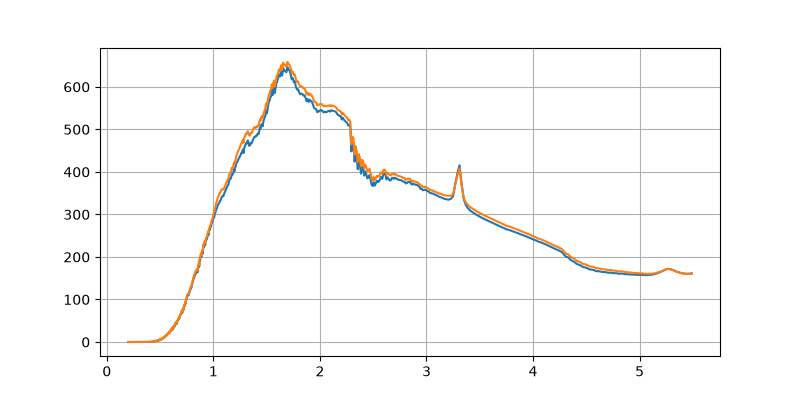

In [32]:
idx = 0

x_test_one = x_test[idx]
prediction = emulator.predict_one(x_test_one)
flux_pred = prediction["flux"]

plt.close()
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(lbs, flux_test[idx])
ax.plot(lbs, flux_pred)
ax.grid()
print(list(prediction.keys()))

We can send an entire dataset to the emulator.  
Noted that we first want to send it to a device, either `cuda` or `mps` if GPU supports.  
We can do it with `.to("auto")` method, or specify the device you want by `.to("cuda")` (Nvidia) or `to("mps")` (mac apple chips)

When `predict_one()`, you shouldn't move the emulator to a different device other than `"cpu"`, because if you were to repeatedly call it (for example in MCMC), the overhead time will make it extremely slow.  
If you have run `predict` on devices that are not cpu, you should move it back to cpu if you want to run `predict_one()`

In [ ]:
emulator.to("auto")
print("Using device:", emulator.device)

Using device:  mps


In [45]:
all_preds = emulator.predict(x_test, batch_size=1000)

we can pick random source to show the result

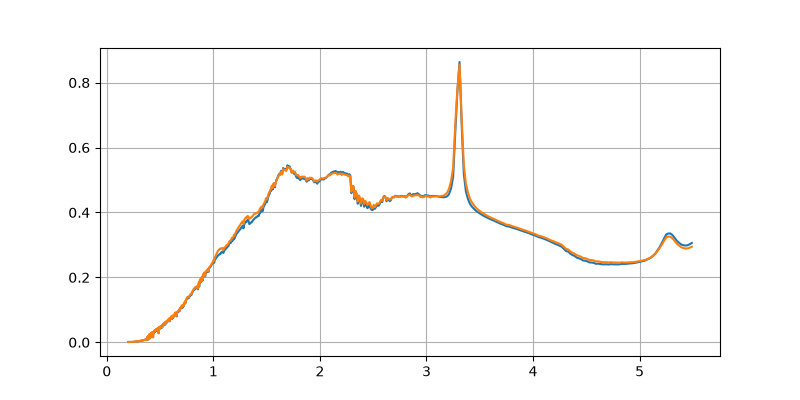

In [44]:
idx = np.random.choice(len(x_test))

flux_pred = all_preds["flux"][idx]

plt.close()
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(lbs, flux_test[idx])
ax.plot(lbs, flux_pred)
ax.grid()
